Para el Módulo 1, aislar las columnas que contienen la información clínica:

- FullReport: El texto narrativo completo (es el corazón de tu NLP).

- BI-RADS: Tu variable objetivo (la etiqueta que la IA debe aprender a predecir).

- Conclusions y Recommendations: Útiles para validar si tu IA está extrayendo bien la lógica médica.

In [30]:
import pandas as pd

# 1. Cargamos con los parámetros que ya probamos
try:
    df = pd.read_csv(r'C:\Users\sebas\OneDrive\Escritorio\Doctorado\1 Semestre\Electivo - BME513 - Inteligencia Artificial en Salud\proyecto-ia-mamografia\data\raw\BIRADS_radiology_reports.csv', sep=';', encoding='utf-8')

    # 2. Verificamos qué es 'df'
    print(f"Tipo de objeto: {type(df)}")
    
    # 3. Si es un DataFrame, imprimimos las columnas para confirmar que existen
    if isinstance(df, pd.DataFrame):
        print(f"Columnas encontradas: {df.columns.tolist()}")
        # Solo ahora intentamos seleccionar
        df_work = df[['Full_Report', 'Conclusion', 'Recommendations', 'BI-RADS']].copy()
        print("¡Éxito! Selección realizada.")
    else:
        print("El archivo no se cargó como un DataFrame.")


except Exception as e:
    print(f"Error al cargar o procesar: {e}")
print(df.columns.tolist())

Tipo de objeto: <class 'pandas.DataFrame'>
Columnas encontradas: ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children']
¡Éxito! Selección realizada.
['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children']


Limpieza inicial
Limpieza simple y segura: minúsculas, eliminar espacios extra, quitar saltos de línea y normalizar caracteres raros. En texto clínico conviene ser conservador: no borres números ni palabras médicas importantes todavía, porque pueden ser útiles para BI-RADS y recomendaciones

In [31]:
import re
import unicodedata
import pandas as pd

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.strip()
    return texto


df_work['Full_Report_clean'] = df_work['Full_Report'].apply(limpiar_texto)
df_work['Conclusion_clean'] = df_work['Conclusion'].apply(limpiar_texto)
df_work['Recommendations_clean'] = df_work['Recommendations'].apply(limpiar_texto)


Revisar nulos
Después revisa cuántos valores faltan en cada columna para decidir si eliminas filas o si las completas con texto vacío. En tu caso, Full_Report y BI-RADS son las columnas más importantes

In [32]:
#Revisar nulos
df_work.isnull().sum()

Full_Report               0
Conclusion                0
Recommendations          10
BI-RADS                   0
Full_Report_clean         0
Conclusion_clean          0
Recommendations_clean     0
dtype: int64

Ver primeras filas
Para comprobar que el texto quedó bien, mira una muestra pequeña con las columnas originales y limpias. Eso te ayudará a detectar si la limpieza fue demasiado agresiva.

In [33]:
df_work[['Full_Report', 'Full_Report_clean', 'BI-RADS']].head(3)


,Full_Report,Full_Report_clean,BI-RADS
0,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,mamografia digital bilateral craneo-caudal y m...,0
1,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,mamografia digital bilateral craneo-caudal y m...,2
2,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,mamografia digital bilateral craneo-caudal y m...,0


El siguiente paso es medir el desbalance con value_counts() en BI-RADS y revisar cuántos ejemplos hay por clase. En datasets clínicos, la evaluación debe centrarse en macro F1, porque el promedio simple puede ocultar el mal desempeño en clases minoritarias.

In [34]:
df_work['BI-RADS'].value_counts(dropna=False)


BI-RADS
2    2635
0     966
1     596
3      87
4      52
5      16
6       5
Name: count, dtype: int64

 Los nulos de Recommendations
Convertire nulos a texto vacío sin romper el flujo. Si después uso esa columna para validación, simplemente guardo ese campo como ausente y lo excluyo de esa parte de la lógica.

In [35]:

df_work['Recommendations'] = df_work['Recommendations'].fillna('sin_recomendacion')


In [36]:
#Revisar nulos
df_work.isnull().sum()


Full_Report              0
Conclusion               0
Recommendations          0
BI-RADS                  0
Full_Report_clean        0
Conclusion_clean         0
Recommendations_clean    0
dtype: int64

Exploración rápida del dataset para entender la distribución de BI-RADS y decidir cómo vas a entrenar el modelo. En mamografía, BI-RADS es la categoría estandarizada que resume el hallazgo y guía la conducta clínica, así que esa será tu variable objetivo principal

In [37]:
# 1. Distribución de clases
print(df_work['BI-RADS'].value_counts(dropna=False))

# 2. Porcentaje por clase
print(df_work['BI-RADS'].value_counts(normalize=True, dropna=False) * 100)

# 3. Largo de los textos
df_work['len_report'] = df_work['Full_Report'].astype(str).str.len()
print(df_work['len_report'].describe())


BI-RADS
2    2635
0     966
1     596
3      87
4      52
5      16
6       5
Name: count, dtype: int64
BI-RADS
2    60.477393
0    22.171219
1    13.679137
3     1.996787
4     1.193482
5     0.367225
6     0.114758
Name: proportion, dtype: float64
count    4357.000000
mean      791.643562
std       183.155887
min       444.000000
25%       653.000000
50%       754.000000
75%       912.000000
max      1684.000000
Name: len_report, dtype: float64


En esta etapa realicé un análisis exploratorio de la variable objetivo BI-RADS. Revisé la frecuencia de cada clase, calculé sus proporciones y observé la longitud de los informes, con el fin de evaluar el nivel de desbalance del conjunto de datos y definir la estrategia de modelado más adecuada - Separare los resultados para mejor visualizacion.


Código para el conteo

BI-RADS
0     966
1     596
2    2635
3      87
4      52
5      16
6       5
Name: count, dtype: int64
BI-RADS
0    22.17
1    13.68
2    60.48
3     2.00
4     1.19
5     0.37
6     0.11
Name: proportion, dtype: float64


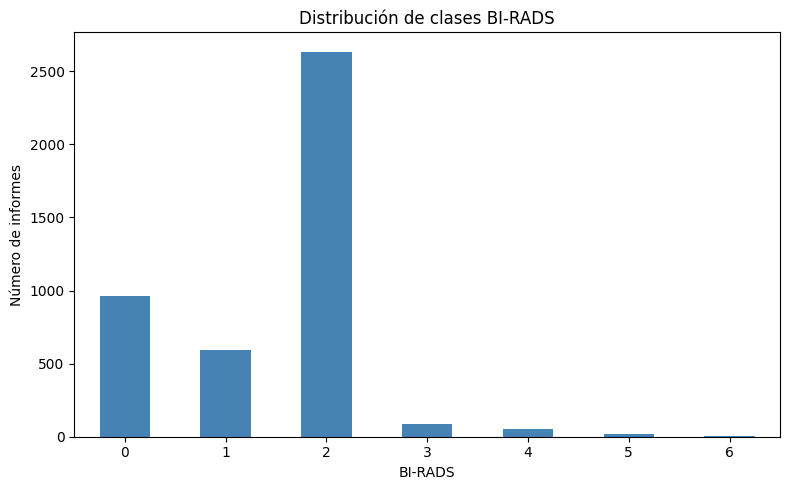

In [38]:
import matplotlib.pyplot as plt


# Conteo y porcentaje de BI-RADS
conteo_birads = df_work['BI-RADS'].value_counts().sort_index()
porcentaje_birads = df_work['BI-RADS'].value_counts(normalize=True).sort_index() * 100

print(conteo_birads)
print(porcentaje_birads.round(2))

plt.figure(figsize=(8, 5))
conteo_birads.plot(kind='bar', color='steelblue')
plt.title('Distribución de clases BI-RADS')
plt.xlabel('BI-RADS')
plt.ylabel('Número de informes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Además del conteo absoluto de clases, incorporé una visualización proporcional y un análisis de la longitud de los informes. Esto me permitió observar no solo cuántos casos hay por categoría, sino también cómo se distribuyen en relación con el total y qué tan largos son los reportes que serán usados como entrada al modelo.

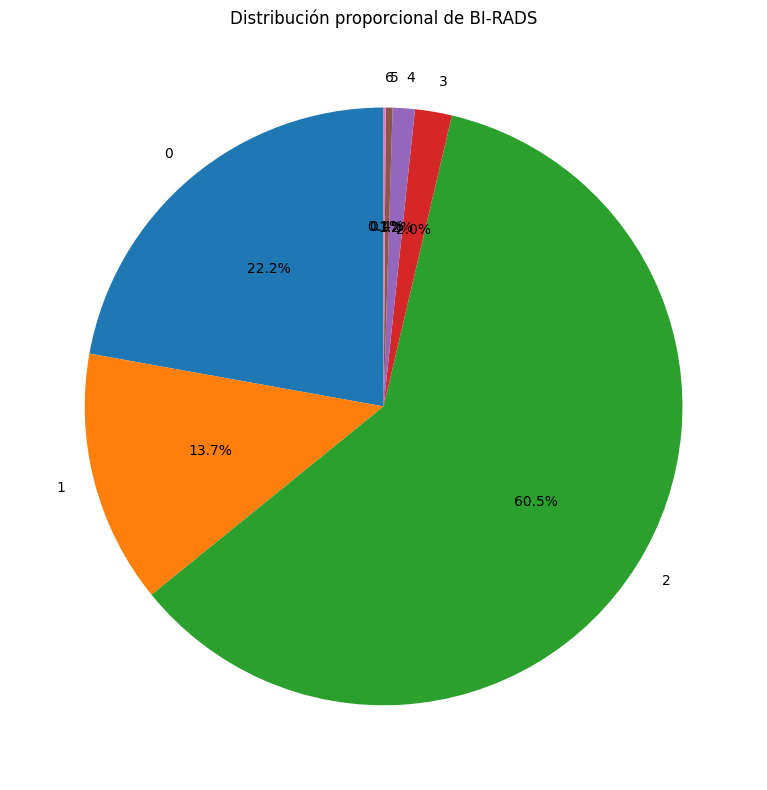

In [39]:
import matplotlib.pyplot as plt

conteo_birads = df_work['BI-RADS'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(
    conteo_birads,
    labels=conteo_birads.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribución proporcional de BI-RADS')
plt.tight_layout()
plt.show()


In [40]:
resumen_birads = pd.DataFrame({
    'Conteo': df_work['BI-RADS'].value_counts().sort_index(),
    'Porcentaje': (df_work['BI-RADS'].value_counts(normalize=True).sort_index() * 100).round(2)
})

resumen_birads


,Conteo,Porcentaje
BI-RADS,,
0,966,22.17
1,596,13.68
2,2635,60.48
3,87,2.00
4,52,1.19
5,16,0.37
6,5,0.11


Además de analizar la distribución de BI-RADS, revisé la longitud de los informes para entender cuántos caracteres aporta cada texto y definir un tamaño de entrada razonable para el modelo de lenguaje. Este análisis es importante porque los informes radiológicos pueden ser extensos y no todos los modelos aceptan secuencias largas sin truncamiento.

In [41]:
df_work['len_report'] = df_work['Full_Report_clean'].astype(str).str.len()

print(df_work['len_report'].describe())


count    4357.000000
mean      779.032132
std       181.742662
min       436.000000
25%       640.000000
50%       740.000000
75%       898.000000
max      1666.000000
Name: len_report, dtype: float64


Código para histograma

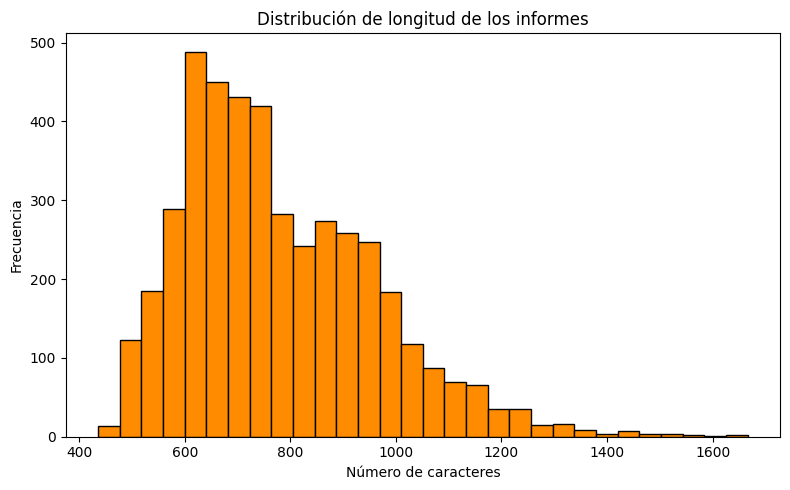

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_work['len_report'], bins=30, color='darkorange', edgecolor='black')
plt.title('Distribución de longitud de los informes')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


La distribución de longitud muestra que la mayoría de los informes tienen tamaños relativamente similares, aunque existe variabilidad entre casos. Esto sugiere que, al modelar el texto, será necesario definir una longitud máxima de entrada que conserve suficiente información clínica sin exceder la capacidad del modelo.

Guardado de Dataset modificado

In [48]:
from pathlib import Path

Path('data/processed').mkdir(parents=True, exist_ok=True)
df_work.to_csv('data/processed/reports_cleaned.csv', index=False)


In [49]:
df_work = pd.read_csv('data/processed/reports_cleaned.csv')
